<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/CNN/shreya_earlystage_fusion_test(with_4comparisons_peyton).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Convolutional Neural Networks in PyTorch

This notebook walks through the application of **convolutional neural networks (CNNs)** using PyTorch.

We will study two examples:

1. A **2D CNN for image classification** on the MNIST handwritten digit dataset.
2. A **1D CNN for time-series classification** on a synthetic signal dataset.

The goal is to mirror the ideas from the NumPy implementation, but now using PyTorch's built-in tools:

- `torch.Tensor`
- `torch.nn.Module`
- `torch.nn.Conv2d`
- `torch.nn.Conv1d`
- `torch.nn.ReLU`
- `torch.nn.MaxPool2d`
- `torch.nn.Linear`
- `torch.optim`
- automatic differentiation through `loss.backward()`

PyTorch handles the tedious backpropagation bookkeeping for us, but the mathematical structure is the same as the NumPy version.



## 1. What is a Convolutional Neural Network?

A fully connected neural network treats each input feature as separate. For images, this ignores spatial structure. A CNN instead uses **filters**, also called **kernels**, that slide across an input and detect local patterns.

For a 2D image, a convolutional layer learns filters that may detect edges, corners, curves, or other local image features.

For a 1D time series, a convolutional layer learns filters that may detect spikes, oscillations, trends, or short temporal patterns.

A typical CNN layer sequence is:

\[
\text{Input} \rightarrow \text{Convolution} \rightarrow \text{Activation} \rightarrow \text{Pooling} \rightarrow \text{Dense Layers} \rightarrow \text{Prediction}.
\]

In PyTorch, these operations are represented as neural network layers.



## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


True
Using device: cuda


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/
# !ls

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [15]:
# print(next(ts_model.parameters()).is_cuda)
# unique, counts = torch.unique(y_ts_tensor, return_counts=True)
# for cls, cnt in zip(unique.tolist(), counts.tolist()):
#     print(f"Class {cls}: {cnt} samples ({cnt/len(y_ts_tensor)*100:.1f}%)")

In [13]:
import pandas as pd

ECG_data_1K = np.load('/content/ECG_waveforms_1K.npy')
Echo_5K = pd.read_csv('/content/EchoNext_EchoData_5K.csv')

#labels
labels = Echo_5K['shd_moderate_or_greater_flag']
negative = labels==0
positive = labels==1

#initial definitions - ECGs
X = ECG_data_1K # Use all available ECG data
# Ensure y_ts, X_ts, and demog_metric have the same number of samples
y_ts = np.array(labels[:X.shape[0]])
X_ts = np.swapaxes(X, 1, 2)
print(X_ts.shape)
print(y_ts.shape)

#initial definitions - metrics
y_metric = np.array(labels[:X.shape[0]])
demog_metric = Echo_5K[['age_at_ecg', 'sex', 'race_ethnicity',
                      'ventricular_rate', 'atrial_rate', 'pr_interval',
                      'qrs_duration', 'qt_corrected']]
demog_metric = np.array(demog_metric[:X.shape[0]])
print(demog_metric[50])

(1000, 12, 2500)
(1000,)
[64 'male' 'white' 77 77.0 156.0 76 405]



## 14. Train the 1D CNN


In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# ─────────────────────────────────────────────
# 0.  Device
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ─────────────────────────────────────────────
# 1.  Demographic pre-processing
# ─────────────────────────────────────────────
CATEGORICAL_COLS = ["race_ethnicity", "sex"]
CONTINUOUS_COLS  = [
    "age_at_ecg",
    "ventricular_rate",
    "atrial_rate",
    "pr_interval",
    "qrs_duration",
    "qt_corrected"
]

ALL_DEMO_COLS = CATEGORICAL_COLS + CONTINUOUS_COLS


def preprocess_demographics(
    df:     pd.DataFrame,
    scaler: StandardScaler = None,
    knn_k:  int = 5,
    fit:    bool = True,
) -> tuple[np.ndarray, StandardScaler, list[str]]:
    """
    Returns
    -------
    demo_array    : float32 array, shape (N, demo_dim)
    scaler        : fitted StandardScaler  (reuse at inference)
    feature_names : column names after OHE (useful for inspection)
    """
    df = df[ALL_DEMO_COLS].copy()

    # ── KNN imputation ────────────────────────────────────────────────────
    cat_codes = df[CATEGORICAL_COLS].apply(
        lambda col: col.astype("category").cat.codes.replace(-1, np.nan)
    )
    cont_part     = df[CONTINUOUS_COLS].astype(float)
    imputer_input = pd.concat([cat_codes, cont_part], axis=1)

    imputer = KNNImputer(n_neighbors=knn_k)
    imputed = imputer.fit_transform(imputer_input)   # stateless; fine per-call
    imputed_df = pd.DataFrame(imputed, columns=ALL_DEMO_COLS, index=df.index)

    # Decode categorical codes back to string labels
    for col in CATEGORICAL_COLS:
        original_cats = df[col].astype("category").cat.categories
        codes_rounded = imputed_df[col].round().astype(int).clip(0, len(original_cats) - 1)
        imputed_df[col] = original_cats[codes_rounded].values

    # ── One-hot encode ────────────────────────────────────────────────────
    ohe_df        = pd.get_dummies(imputed_df, columns=CATEGORICAL_COLS, dtype=float)
    feature_names = list(ohe_df.columns)

    # ── Standardise continuous columns ────────────────────────────────────
    if scaler is None:
        scaler = StandardScaler()
    cont_indices = [feature_names.index(c) for c in CONTINUOUS_COLS]
    arr = ohe_df.values.astype(np.float32)
    if fit:
        arr[:, cont_indices] = scaler.fit_transform(arr[:, cont_indices])
    else:
        arr[:, cont_indices] = scaler.transform(arr[:, cont_indices])

    return arr, scaler, feature_names


# ─────────────────────────────────────────────
# 2.  Dataset & DataLoaders
# ─────────────────────────────────────────────
class FusedDataset(Dataset):
    def __init__(self, X_ts: np.ndarray, X_demo: np.ndarray, y: np.ndarray):
        assert len(X_ts) == len(X_demo) == len(y), "Length mismatch."
        self.X_ts   = torch.tensor(X_ts,   dtype=torch.float32)
        self.X_demo = torch.tensor(X_demo, dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_ts[idx], self.X_demo[idx], self.y[idx]


def build_loaders(
    X_ts:        np.ndarray,
    X_demo:      np.ndarray,
    y:           np.ndarray,
    train_frac:  float = 0.8,
    batch_train: int   = 32,
    batch_test:  int   = 128,
    seed:        int   = 42,
):
    dataset    = FusedDataset(X_ts, X_demo, y)
    train_size = int(train_frac * len(dataset))
    test_size  = len(dataset) - train_size
    train_ds, test_ds = random_split(
        dataset, [train_size, test_size],
        generator=torch.Generator().manual_seed(seed),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_train, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_test,  shuffle=False)

    print(f"Training samples : {len(train_ds)}")
    print(f"Test samples     : {len(test_ds)}")
    print(f"Demo feature dim : {X_demo.shape[1]}")
    wv, dm, lb = next(iter(train_loader))
    print(f"Batch waveform   : {wv.shape}")
    print(f"Batch demo       : {dm.shape}")

    return train_loader, test_loader


# ─────────────────────────────────────────────
# 3.  FiLM conditioning layer
# ─────────────────────────────────────────────
class FiLMLayer(nn.Module):
    """
    Applies Feature-wise Linear Modulation to a 1-D conv feature map.

        FiLM(h) = γ ⊙ h + β

    γ and β are produced by a small Linear projection of the demographic
    embedding; each has shape (B, num_channels, 1) so the modulation is
    applied identically across the time dimension but differently per channel.

    Parameters
    ----------
    demo_embed_dim : dimensionality of the shared demographic embedding
    num_channels   : number of output channels of the preceding Conv1d
    """

    def __init__(self, demo_embed_dim: int, num_channels: int):
        super().__init__()
        # Projects shared demo embedding → 2 × num_channels scalars (γ and β)
        self.film_proj = nn.Linear(demo_embed_dim, 2 * num_channels)
        self.num_channels = num_channels

        nn.init.zeros_(self.film_proj.weight)
        nn.init.zeros_(self.film_proj.bias)
        with torch.no_grad():
            self.film_proj.bias[:num_channels] = 1.0

    def forward(self, h: torch.Tensor, demo_embed: torch.Tensor) -> torch.Tensor:
        """
        h          : (B, C, L)  — CNN feature map
        demo_embed : (B, demo_embed_dim) — shared demographic embedding
        """
        params = self.film_proj(demo_embed)           # (B, 2C)
        gamma, beta = params.chunk(2, dim=-1)         # each (B, C)
        gamma = gamma.unsqueeze(-1)                   # (B, C, 1)
        beta  = beta.unsqueeze(-1)                    # (B, C, 1)
        return gamma * h + beta                       # broadcast over L


# ─────────────────────────────────────────────
# 4.  FiLM-conditioned CNN block
# ─────────────────────────────────────────────
class FiLMConvBlock(nn.Module):
    """
    One convolutional block with FiLM conditioning:

        Conv1d → FiLM(demo) → ReLU → Dropout → AvgPool1d

    The activation comes AFTER FiLM so γ/β can shift the operating point
    of the non-linearity (standard FiLM convention).
    """

    def __init__(
        self,
        in_channels:    int,
        out_channels:   int,
        kernel_size:    int,
        padding:        int,
        pool_size:      int,
        dropout:        float,
        demo_embed_dim: int,
    ):
        super().__init__()
        self.conv    = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding)
        self.film    = FiLMLayer(demo_embed_dim, out_channels)
        self.act     = nn.ReLU()
        self.drop    = nn.Dropout(dropout)
        self.pool    = nn.AvgPool1d(kernel_size=pool_size)

    def forward(self, x: torch.Tensor, demo_embed: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)           # (B, out_channels, L)
        x = self.film(x, demo_embed)   # modulate with demographics
        x = self.act(x)
        x = self.drop(x)
        x = self.pool(x)
        return x


# ─────────────────────────────────────────────
# 5.  Full model
# ─────────────────────────────────────────────
class HeartDiseaseNet(nn.Module):
    """
    FiLM-conditioned 1-D CNN for ECG + demographics.

    The demographic vector is first projected to a shared embedding
    (demo_embed_dim).  That embedding feeds FiLM layers inside every
    convolutional block, so demographic context influences how every
    filter responds to the waveform at every spatial position.

    Architecture summary
    --------------------
      DemoEncoder : Linear(demo_dim → demo_embed_dim) → ReLU

      Block 1: Conv1d( in_ch,  4, k=15) → FiLM → ReLU → Drop(0.20) → AvgPool(5)
      Block 2: Conv1d(   4,   8, k= 9) → FiLM → ReLU → Drop(0.30) → AvgPool(5)
      Block 3: Conv1d(   8,  12, k= 5) → FiLM → ReLU → Drop(0.30) → AvgPool(5)
      Block 4: Conv1d(  12,  16, k= 3) → FiLM → ReLU → Drop(0.30) → AvgPool(5)

      Head   : Flatten → Linear(flat, 64) → ReLU → Drop(0.30) → Linear(64, num_classes)
    """

    def __init__(
        self,
        sequence_length: int = 2500,
        in_channels:     int = 12,
        demo_dim:        int = 20,    # set after preprocessing
        num_classes:     int = 2,
        demo_embed_dim:  int = 32,    # shared demographic embedding size
    ):
        super().__init__()

        # ── Demographic encoder (shared; feeds all FiLM layers) ───────────
        self.demo_encoder = nn.Sequential(
            nn.Linear(demo_dim, demo_embed_dim),
            nn.ReLU(),
        )

        # ── FiLM-conditioned conv blocks ──────────────────────────────────
        self.block1 = FiLMConvBlock(in_channels, 4,  kernel_size=15, padding=7,  pool_size=5, dropout=0.20, demo_embed_dim=demo_embed_dim)
        self.block2 = FiLMConvBlock(4,           8,  kernel_size=9,  padding=4,  pool_size=5, dropout=0.40, demo_embed_dim=demo_embed_dim)
        self.block3 = FiLMConvBlock(8,           12, kernel_size=5,  padding=2,  pool_size=5, dropout=0.40, demo_embed_dim=demo_embed_dim)
        self.block4 = FiLMConvBlock(12,          16, kernel_size=3,  padding=2,  pool_size=5, dropout=0.30, demo_embed_dim=demo_embed_dim)

        #self.block1 = FiLMConvBlock(in_channels, 8,  kernel_size=15, padding=7, pool_size=5, dropout=0.20, demo_embed_dim=demo_embed_dim)
        #self.block2 = FiLMConvBlock(8,           16, kernel_size=9,  padding=4, pool_size=5, dropout=0.30, demo_embed_dim=demo_embed_dim)
        #self.block3 = FiLMConvBlock(16,          24, kernel_size=5,  padding=2, pool_size=5, dropout=0.35, demo_embed_dim=demo_embed_dim)
        #self.block4 = FiLMConvBlock(24,          32, kernel_size=3,  padding=2, pool_size=5, dropout=0.35, demo_embed_dim=demo_embed_dim)
        # ── Dynamically compute flattened size ────────────────────────────
        with torch.no_grad():
            dummy_ts   = torch.zeros(1, in_channels, sequence_length)
            dummy_demo = torch.zeros(1, demo_embed_dim)   # already embedded
            x = self.block1(dummy_ts,   dummy_demo)
            x = self.block2(x,          dummy_demo)
            x = self.block3(x,          dummy_demo)
            x = self.block4(x,          dummy_demo)
            flat_sz = x.shape[1] * x.shape[2]
        print(f"Flattened size after FiLM-CNN blocks: {flat_sz}")

        # ── Classification head ───────────────────────────────────────────
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_sz, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes),
        )

    def forward(self, x_ts: torch.Tensor, x_demo: torch.Tensor) -> torch.Tensor:
        """
        x_ts   : (B, in_channels, sequence_length)
        x_demo : (B, demo_dim)
        """
        demo_embed = self.demo_encoder(x_demo)   # (B, demo_embed_dim)

        x = self.block1(x_ts, demo_embed)
        x = self.block2(x,    demo_embed)
        x = self.block3(x,    demo_embed)
        x = self.block4(x,    demo_embed)

        return self.head(x)                      # (B, num_classes)


# ─────────────────────────────────────────────
# 6.  Training & evaluation
# ─────────────────────────────────────────────
def evaluate_classifier(model, data_loader, criterion=None):
    model.eval()
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in data_loader:
            X_ts_b, X_demo_b, y_b = X_ts_b.to(device), X_demo_b.to(device), y_b.to(device)
            logits      = model(X_ts_b, X_demo_b)
            loss        = criterion(logits, y_b)
            b           = X_ts_b.shape[0]
            total_loss += loss.item() * b
            correct    += (torch.argmax(logits, dim=1) == y_b).sum().item()
            total      += b
    return total_loss / total, correct / total


def train_classifier(
    model,
    train_loader,
    test_loader   = None,
    epochs        = 50,
    learning_rate = 1e-3,
    verbose       = True,
):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=2e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=1e-6
)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for X_ts_b, X_demo_b, y_b in train_loader:
            X_ts_b, X_demo_b, y_b = X_ts_b.to(device), X_demo_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(X_ts_b, X_demo_b)
            loss   = criterion(logits, y_b)
            loss.backward()
            optimizer.step()

            b           = X_ts_b.shape[0]
            total_loss += loss.item() * b
            correct    += (torch.argmax(logits, dim=1) == y_b).sum().item()
            total      += b

        scheduler.step()
        train_loss = total_loss / total
        train_acc  = correct   / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if test_loader is not None:
            test_loss, test_acc = evaluate_classifier(model, test_loader, criterion)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)
            if verbose:
                print(
                    f"Epoch {epoch+1}/{epochs}: "
                    f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
                    f"test loss={test_loss:.4f},  test acc={test_acc:.4f}, "
                    f"lr={optimizer.param_groups[0]['lr']:.2e}"
                )
        else:
            if verbose:
                print(
                    f"Epoch {epoch+1}/{epochs}: "
                    f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
                    f"lr={optimizer.param_groups[0]['lr']:.2e}"
                )

    return history


# ─────────────────────────────────────────────
# 7.  Example usage  (replace with real data)
# ─────────────────────────────────────────────
if __name__ == "__main__":
    # Use the pre-loaded data (ECG_data_1K, Echo_5K, labels) instead of generating random data
    N = len(y_ts) # Get N from the actual data length

    # Prepare demographic DataFrame from Echo_5K
    # Ensure the column names match ALL_DEMO_COLS used in preprocess_demographics
    demo_df = Echo_5K[ALL_DEMO_COLS].iloc[:N].copy()

    # It's good practice to handle potential missing values explicitly before preprocessing,
    # or ensure preprocess_demographics can handle them robustly.
    # The preprocess_demographics already includes KNN imputation, so we can proceed.

    # Preprocess the actual demographic data
    demog_metrics_processed, scaler, feature_names = preprocess_demographics(demo_df, fit=True)
    demo_dim = demog_metrics_processed.shape[1]
    print(f"\nDemo features ({demo_dim}): {feature_names}\n")


    # Build DataLoaders using the loaded X_ts, y_ts, and the preprocessed demographics
    train_loader, test_loader = build_loaders(
        X_ts, demog_metrics_processed, y_ts, train_frac=0.8, batch_train=32, batch_test=128
    )

    model = HeartDiseaseNet(
        sequence_length = X_ts.shape[2], # Use actual sequence length
        in_channels     = X_ts.shape[1], # Use actual number of channels
        demo_dim        = demo_dim,
        num_classes     = 2,
        demo_embed_dim  = 32,
    )
    print(model)

    history = train_classifier(
        model, train_loader, test_loader=test_loader, epochs=40, learning_rate=5e-4
    )

Using device: cuda

Demo features (14): ['age_at_ecg', 'ventricular_rate', 'atrial_rate', 'pr_interval', 'qrs_duration', 'qt_corrected', 'race_ethnicity_asian', 'race_ethnicity_black', 'race_ethnicity_hispanic', 'race_ethnicity_other', 'race_ethnicity_unknown', 'race_ethnicity_white', 'sex_female', 'sex_male']

Training samples : 800
Test samples     : 200
Demo feature dim : 14
Batch waveform   : torch.Size([32, 12, 2500])
Batch demo       : torch.Size([32, 14])
Flattened size after FiLM-CNN blocks: 64
HeartDiseaseNet(
  (demo_encoder): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): ReLU()
  )
  (block1): FiLMConvBlock(
    (conv): Conv1d(12, 4, kernel_size=(15,), stride=(1,), padding=(7,))
    (film): FiLMLayer(
      (film_proj): Linear(in_features=32, out_features=8, bias=True)
    )
    (act): ReLU()
    (drop): Dropout(p=0.2, inplace=False)
    (pool): AvgPool1d(kernel_size=(5,), stride=(5,), padding=(0,))
  )
  (block2): FiLMConvBlock(
    (conv)

In [18]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    log_loss,
    brier_score_loss,
)


def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Computes the Expected Calibration Error (ECE).

    Bins predictions by predicted probability into n_bins equal-width bins,
    then measures the weighted average gap between predicted confidence
    and actual accuracy within each bin.

    ECE = sum over bins of (n_bin / N) * |accuracy_bin - confidence_bin|
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n_total = len(y_true)

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        # include right edge on the last bin
        if i == n_bins - 1:
            in_bin = (y_prob >= lo) & (y_prob <= hi)
        else:
            in_bin = (y_prob >= lo) & (y_prob < hi)

        n_bin = in_bin.sum()
        if n_bin == 0:
            continue

        acc_bin        = y_true[in_bin].mean()
        confidence_bin = y_prob[in_bin].mean()
        ece           += (n_bin / n_total) * abs(acc_bin - confidence_bin)

    return ece


def evaluate_model(model, data_loader, device, threshold=0.5):
    """
    Runs the model over data_loader and computes a full suite of
    classification metrics for the positive class (assumed label=1).

    Works for models with signature model(X_ts, X_demo) -> logits (B, 2).
    Adjust the forward call below if your model signature differs.

    Returns
    -------
    dict of metric_name -> value
    """
    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            # adjust unpacking if your loader yields a different structure
            if len(batch) == 3:
                X_ts_b, X_demo_b, y_b = batch
                X_ts_b   = X_ts_b.to(device)
                X_demo_b = X_demo_b.to(device)
                logits   = model(X_ts_b, X_demo_b)
            else:
                X_b, y_b = batch
                X_b      = X_b.to(device)
                logits   = model(X_b)

            probs = F.softmax(logits, dim=1)[:, 1]   # P(class=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y_b.numpy())

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)
    y_pred = (y_prob >= threshold).astype(int)

    # ── confusion matrix ───────────────────────────────────────────────────
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # ── core classification metrics ───────────────────────────────────────
    accuracy          = accuracy_score(y_true, y_pred)
    balanced_accuracy  = balanced_accuracy_score(y_true, y_pred)
    sensitivity       = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall / TPR
    specificity       = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # TNR

    # ── probabilistic metrics ──────────────────────────────────────────────
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)

    # negative log-likelihood (log loss); clip probs to avoid log(0)
    y_prob_clipped = np.clip(y_prob, 1e-7, 1 - 1e-7)
    nll = log_loss(y_true, y_prob_clipped)

    # brier score: mean squared error between predicted prob and true label
    brier = brier_score_loss(y_true, y_prob)

    # expected calibration error
    ece = expected_calibration_error(y_true, y_prob, n_bins=10)

    # ── prevalence ──────────────────────────────────────────────────────────
    positive_prevalence = y_true.mean()

    metrics = {
        "accuracy":                 accuracy,
        "balanced_accuracy":        balanced_accuracy,
        "auroc":                    auroc,
        "auprc":                    auprc,
        "sensitivity":              sensitivity,
        "specificity":              specificity,
        "negative_log_likelihood":  nll,
        "brier_score":              brier,
        "expected_calibration_error": ece,
        "tn": float(tn),
        "fp": float(fp),
        "fn": float(fn),
        "tp": float(tp),
        "positive_prevalence":      positive_prevalence,
    }

    return metrics


def print_metrics(metrics: dict):
    """Pretty-print metrics dict matching the format you'd report/log."""
    print(f"accuracy {metrics['accuracy']:.6f}")
    print(f"balanced_accuracy {metrics['balanced_accuracy']:.6f}")
    print(f"auroc {metrics['auroc']:.6f}")
    print(f"auprc {metrics['auprc']:.6f}")
    print(f"sensitivity {metrics['sensitivity']:.6f}")
    print(f"specificity {metrics['specificity']:.6f}")
    print(f"negative_log_likelihood {metrics['negative_log_likelihood']:.6f}")
    print(f"brier_score {metrics['brier_score']:.6f}")
    print(f"expected_calibration_error {metrics['expected_calibration_error']:.6f}")
    print(f"tn {metrics['tn']:.6f}")
    print(f"fp {metrics['fp']:.6f}")
    print(f"fn {metrics['fn']:.6f}")
    print(f"tp {metrics['tp']:.6f}")
    print(f"positive_prevalence {metrics['positive_prevalence']:.6f}")


if __name__ == "__main__":
    # ── example usage ──────────────────────────────────────────────────────
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # metrics = evaluate_model(model, test_loader, device)
    # print_metrics(metrics)
    pass
# The following lines caused the NameError and have been corrected:
# model = TimeSeriesConvNet
# test_loader = ts_test_loader

# The model and test_loader are already defined and available from the previous __main__ block (cell LhQwoqzEIjpN)
# as 'model' (an instance of HeartDiseaseNet) and 'test_loader'.

metrics = evaluate_model(model, test_loader, device)
print_metrics(metrics)


accuracy 0.765000
balanced_accuracy 0.765000
auroc 0.835800
auprc 0.856502
sensitivity 0.710000
specificity 0.820000
negative_log_likelihood 0.494824
brier_score 0.162690
expected_calibration_error 0.046317
tn 82.000000
fp 18.000000
fn 29.000000
tp 71.000000
positive_prevalence 0.500000


In [19]:
class SimpleConcatNet(nn.Module):
    def __init__(self, sequence_length, in_channels, demo_dim, num_classes=2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 4, 15, padding=7), nn.ReLU(), nn.Dropout(0.2), nn.AvgPool1d(5),
            nn.Conv1d(4, 8, 9, padding=4), nn.ReLU(), nn.Dropout(0.3), nn.AvgPool1d(5),
            nn.Conv1d(8, 12, 5, padding=2), nn.ReLU(), nn.Dropout(0.3), nn.AvgPool1d(5),
            nn.Conv1d(12, 16, 3, padding=2), nn.ReLU(), nn.Dropout(0.3), nn.AvgPool1d(5),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, sequence_length)
            flat_sz = self.cnn(dummy).flatten(1).shape[1]

        self.head = nn.Sequential(
            nn.Linear(flat_sz + demo_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x_ts, x_demo):
        h = self.cnn(x_ts).flatten(1)
        combined = torch.cat([h, x_demo], dim=1)
        return self.head(combined)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, demog_metrics_processed, y_ts, cv=5)
print(f"Demographics-only accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Demographics-only accuracy: 0.6610 ± 0.0273


In [21]:
import pandas as pd
demo_df_check = pd.DataFrame(demog_metrics_processed, columns=feature_names)
demo_df_check['label'] = y_ts

for col in CONTINUOUS_COLS:
    corr = demo_df_check[col].corr(demo_df_check['label'])
    print(f"{col}: corr={corr:.3f}")

age_at_ecg: corr=0.156
ventricular_rate: corr=0.111
atrial_rate: corr=0.148
pr_interval: corr=0.093
qrs_duration: corr=0.241
qt_corrected: corr=0.242


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    auc,
)

## 2. Prediction objects used by the metrics

In [23]:
def as_numpy(x):
    """Convert torch tensors or array-like objects to NumPy arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def probs_to_predictions(probs, threshold=0.5):
    """
    Convert probabilities to hard class predictions.

    Args:
        probs: Either shape [N] containing P(class 1), or shape [N, 2]
               containing [P(class 0), P(class 1)].
        threshold: Positive-class threshold used if probs has shape [N].

    Returns:
        y_pred: shape [N]
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return (probs >= threshold).astype(int)

    if probs.ndim == 2:
        return np.argmax(probs, axis=1).astype(int)

    raise ValueError("probs must have shape [N] or [N, C].")


def positive_class_probability(probs):
    """
    Extract P(class 1) from either shape [N] or shape [N, 2].
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return probs

    if probs.ndim == 2 and probs.shape[1] == 2:
        return probs[:, 1]

    raise ValueError("For binary metrics, probs must have shape [N] or [N, 2].")

## 3. Collecting predictions from a standard neural network

In [24]:
@torch.no_grad()
def collect_predictions_standard_nn(model, data_loader, device):
    """
    Collect labels and probabilities from a standard deterministic neural network.

    Args:
        model: PyTorch classifier returning logits of shape [batch_size, 2].
        data_loader: DataLoader yielding (x, y).
        device: torch device.

    Returns:
        y_true: shape [N]
        probs: shape [N, 2]
        y_pred: shape [N]
    """
    model.eval() # Corrected: Removed the argument from model.eval()

    all_y = []
    all_probs = []

    for batch in data_loader:
        # Unpack batch based on the structure provided by FusedDataset
        if len(batch) == 3:
            X_ts_b, X_demo_b, y_b = batch
            X_ts_b   = X_ts_b.to(device)
            X_demo_b = X_demo_b.to(device)
            logits   = model(X_ts_b, X_demo_b)
        else:
            # Fallback for models expecting a single input (e.g., just X_ts)
            X_b, y_b = batch
            X_b      = X_b.to(device)
            logits   = model(X_b)

        probs = F.softmax(logits, dim=-1)

        all_y.append(y_b.detach().cpu())
        all_probs.append(probs.detach().cpu())

    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

## 5. Confusion matrix quantities

In [25]:
def confusion_counts(y_true, y_pred):
    """
    Return TN, FP, FN, TP for binary labels 0 and 1.
    """
    y_true = as_numpy(y_true).astype(int)
    y_pred = as_numpy(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn, fp, fn, tp

## 6. Accuracy

In [26]:
def compute_accuracy(y_true, y_pred):
    y_true = as_numpy(y_true)
    y_pred = as_numpy(y_pred)
    return np.mean(y_true == y_pred)

## 7. Sensitivity and specificity

In [27]:
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return sensitivity, specificity

## 8. Balanced accuracy

In [28]:
def compute_balanced_accuracy(y_true, y_pred):
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)
    return 0.5 * (sensitivity + specificity)

## 9. AUROC

In [29]:
def compute_auroc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, p1)


def plot_roc_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    fpr, tpr, thresholds = roc_curve(y_true, p1)
    score = roc_auc_score(y_true, p1)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate / sensitivity")
    plt.title("ROC curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. AUPRC

In [30]:
def compute_auprc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(y_true, p1)


def plot_precision_recall_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    precision, recall, thresholds = precision_recall_curve(y_true, p1)
    score = average_precision_score(y_true, p1)
    prevalence = np.mean(y_true == 1)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    plt.xlabel("Recall / sensitivity")
    plt.ylabel("Precision")
    plt.title("Precision-recall curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Negative log likelihood

In [31]:
def compute_negative_log_likelihood(y_true, probs, eps=1e-12):
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        p1 = np.clip(probs, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))

    if probs.ndim == 2:
        probs = np.clip(probs, eps, 1.0)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return log_loss(y_true, probs, labels=[0, 1])

    raise ValueError("probs must have shape [N] or [N, 2].")

## 12. Brier score

In [32]:
def compute_brier_score(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)
    return np.mean((p1 - y_true) ** 2)

## 13. Expected calibration error

In [33]:
def compute_expected_calibration_error(y_true, probs, n_bins=10):
    """
    Confidence-based ECE for binary or multiclass probabilities.

    Args:
        y_true: shape [N]
        probs: shape [N, C] or shape [N] for binary P(class 1)
        n_bins: number of confidence bins

    Returns:
        ece: scalar
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        prop = np.mean(in_bin)

        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidence[in_bin])
            ece += prop * abs(acc_bin - conf_bin)

    return ece


def calibration_table(y_true, probs, n_bins=10):
    """
    Return bin-level calibration information.
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        n_bin = int(np.sum(in_bin))

        if n_bin > 0:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": n_bin,
                "mean_confidence": float(np.mean(confidence[in_bin])),
                "empirical_accuracy": float(np.mean(correct[in_bin])),
                "abs_gap": float(abs(np.mean(correct[in_bin]) - np.mean(confidence[in_bin]))),
            })
        else:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": 0,
                "mean_confidence": np.nan,
                "empirical_accuracy": np.nan,
                "abs_gap": np.nan,
            })

    return pd.DataFrame(rows)


def plot_calibration_curve(y_true, probs, n_bins=10):
    table = calibration_table(y_true, probs, n_bins=n_bins)
    table_nonempty = table.dropna(subset=["mean_confidence", "empirical_accuracy"])

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.scatter(
        table_nonempty["mean_confidence"],
        table_nonempty["empirical_accuracy"],
        s=50,
        label="Observed bins",
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Calibration curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 14. Plotting ROC Curve Comparisons

In [34]:
def estimate_negative_elbo_per_example_pyro(model, guide, data_loader, device, dataset_size=None):
    """
    Estimate negative ELBO per example for a Pyro Bayesian neural network.

    Args:
        model: Pyro model with forward(x, y=None, dataset_size=None).
        guide: Pyro guide.
        data_loader: DataLoader yielding (x, y).
        device: torch device.
        dataset_size: Optional size used for minibatch scaling. If None, each batch
                      uses its own batch size, which is often appropriate for a
                      held-out evaluation estimate.

    Returns:
        negative_elbo_per_example: scalar float
    """
    try:
        import pyro
        from pyro.infer import Trace_ELBO
    except ImportError as exc:
        raise ImportError("This function requires Pyro. Install pyro-ppl first.") from exc

    model.eval()
    elbo = Trace_ELBO()

    total_loss = 0.0
    total_examples = 0

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        batch_size = x.shape[0]
        ds = dataset_size if dataset_size is not None else batch_size

        loss = elbo.differentiable_loss(model, guide, x, y, ds)

        total_loss += float(loss.detach().cpu())
        total_examples += batch_size

    return total_loss / max(total_examples, 1)


def estimate_cross_entropy_per_example_standard_nn(model, data_loader, device):
    """
    Estimate cross-entropy/NLL per example for a standard neural network.
    This is the standard deterministic analogue of the likelihood part of ELBO.
    """
    model.eval()

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y, reduction="sum")
            total_loss += float(loss.detach().cpu())
            total_examples += x.shape[0]

    return total_loss / max(total_examples, 1)

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y2 = [0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0]

p2 = [[7.37072527e-01, 2.62927413e-01], [6.09507084e-01, 3.90492946e-01], [2.92758167e-01, 7.07241833e-01], [1.58213720e-01, 8.41786265e-01], [6.65924370e-01, 3.34075660e-01], [2.91956425e-01, 7.08043516e-01], [5.99221110e-01, 4.00778830e-01], [4.42056209e-02, 9.55794394e-01], [5.44689953e-01, 4.55310017e-01], [7.13867486e-01, 2.86132574e-01], [5.69620669e-01, 4.30379331e-01], [3.54958087e-01, 6.45041943e-01], [8.82727861e-01, 1.17272168e-01], [2.26851135e-01, 7.73148894e-01], [3.85245174e-01, 6.14754796e-01], [8.51328790e-01, 1.48671210e-01], [7.43409336e-01, 2.56590664e-01], [4.90974784e-01, 5.09025216e-01], [6.33387029e-01, 3.66612941e-01], [6.62468731e-01, 3.37531239e-01], [6.23342514e-01, 3.76657486e-01], [5.73880672e-01, 4.26119357e-01], [2.63593495e-01, 7.36406505e-01], [4.03507739e-01, 5.96492290e-01], [8.64890993e-01, 1.35109052e-01], [8.13726425e-01, 1.86273620e-01], [6.52787983e-01, 3.47212046e-01], [1.21156149e-01, 8.78843904e-01], [6.70871258e-01, 3.29128712e-01], [3.75564426e-01, 6.24435544e-01], [7.88773000e-01, 2.11227000e-01], [1.42553478e-01, 8.57446551e-01], [6.91023409e-01, 3.08976620e-01], [7.47702420e-01, 2.52297640e-01], [7.56013095e-01, 2.43986875e-01], [6.42228901e-01, 3.57771069e-01], [4.69637245e-01, 5.30362725e-01], [7.11931884e-01, 2.88068146e-01], [7.37122416e-01, 2.62877554e-01], [1.33250654e-01, 8.66749346e-01], [1.78407848e-01, 8.21592152e-01], [5.01790464e-01, 4.98209536e-01], [7.63078332e-01, 2.36921653e-01], [8.49634051e-01, 1.50365934e-01], [6.69901788e-01, 3.30098182e-01], [6.33386910e-01, 3.66613030e-01], [4.87157345e-01, 5.12842715e-01], [8.94197106e-01, 1.05802916e-01], [7.66782761e-01, 2.33217195e-01], [7.23672271e-01, 2.76327670e-01], [8.18762660e-01, 1.81237400e-01], [8.04686189e-01, 1.95313856e-01], [4.10192370e-01, 5.89807570e-01], [5.46278596e-01, 4.53721464e-01], [3.52304816e-01, 6.47695184e-01], [2.67490566e-01, 7.32509434e-01], [2.33326256e-01, 7.66673744e-01], [5.93489885e-01, 4.06510115e-01], [7.19611883e-01, 2.80388117e-01], [7.59789169e-01, 2.40210816e-01], [3.18660349e-01, 6.81339622e-01], [3.02785516e-01, 6.97214484e-01], [7.76866734e-01, 2.23133221e-01], [1.55008793e-01, 8.44991207e-01], [9.01227474e-01, 9.87725705e-02], [6.74460232e-01, 3.25539738e-01], [5.69483161e-01, 4.30516809e-01], [6.13459468e-01, 3.86540502e-01], [9.13785875e-01, 8.62141103e-02], [6.79927826e-01, 3.20072144e-01], [4.15975779e-01, 5.84024251e-01], [5.22566080e-01, 4.77433920e-01], [3.49987924e-01, 6.50012136e-01], [7.81153679e-01, 2.18846262e-01], [8.00977588e-01, 1.99022397e-01], [1.17190048e-01, 8.82809997e-01], [9.49552536e-01, 5.04475385e-02], [8.96825433e-01, 1.03174604e-01], [1.45047260e-02, 9.85495329e-01], [3.60044092e-01, 6.39955938e-01], [2.17790589e-01, 7.82209456e-01], [8.33090961e-01, 1.66909024e-01], [7.15391457e-01, 2.84608573e-01], [4.81715560e-01, 5.18284440e-01], [7.84656465e-01, 2.15343475e-01], [5.53673983e-01, 4.46325988e-01], [1.97053105e-02, 9.80294704e-01], [1.12296464e-02, 9.88770366e-01], [1.31367728e-01, 8.68632317e-01], [5.95868647e-01, 4.04131383e-01], [8.01367819e-01, 1.98632210e-01], [8.41106474e-01, 1.58893496e-01], [1.30094835e-04, 9.99869943e-01], [6.43914938e-01, 3.56085032e-01], [6.91433907e-01, 3.08566093e-01], [7.32965231e-01, 2.67034829e-01], [5.91846764e-01, 4.08153236e-01], [4.70682770e-01, 5.29317260e-01], [6.49631083e-01, 3.50368947e-01], [9.06316876e-01, 9.36831459e-02], [4.63206828e-01, 5.36793172e-01], [1.94987178e-01, 8.05012822e-01], [5.29414415e-01, 4.70585585e-01], [7.00745523e-01, 2.99254447e-01], [7.79640019e-01, 2.20359936e-01], [2.54776627e-01, 7.45223343e-01], [7.40919352e-01, 2.59080648e-01], [4.22774076e-01, 5.77225924e-01], [9.02785718e-01, 9.72142816e-02], [9.15220976e-01, 8.47790539e-02], [7.84248948e-01, 2.15751082e-01], [5.27090251e-01, 4.72909749e-01], [6.66134298e-01, 3.33865702e-01], [4.72853720e-01, 5.27146280e-01], [1.49432406e-01, 8.50567579e-01], [2.45233074e-01, 7.54766941e-01], [1.89248919e-01, 8.10751081e-01], [7.69874334e-01, 2.30125666e-01], [7.41610765e-01, 2.58389205e-01], [4.20682997e-01, 5.79316974e-01], [2.17599958e-01, 7.82400012e-01], [6.73196316e-01, 3.26803654e-01], [6.16902709e-01, 3.83097291e-01], [6.25405312e-01, 3.74594659e-01], [4.23817426e-01, 5.76182604e-01], [5.45214653e-01, 4.54785377e-01], [5.59486866e-01, 4.40513104e-01], [1.61273941e-01, 8.38726044e-01], [1.86195690e-03, 9.98138070e-01], [3.69915485e-01, 6.30084574e-01], [7.00899541e-01, 2.99100488e-01], [7.31029510e-01, 2.68970519e-01], [5.41207135e-01, 4.58792806e-01], [4.50658262e-01, 5.49341738e-01], [2.16376454e-01, 7.83623517e-01], [2.27623895e-01, 7.72376120e-01], [7.46866465e-01, 2.53133535e-01], [7.23729968e-01, 2.76270062e-01], [2.30601383e-03, 9.97693956e-01], [7.67646372e-01, 2.32353553e-01], [4.22873497e-01, 5.77126503e-01], [3.51798683e-01, 6.48201346e-01], [8.19059610e-01, 1.80940390e-01], [7.99969912e-01, 2.00030088e-01], [4.45481271e-01, 5.54518759e-01], [8.00222397e-01, 1.99777618e-01], [4.24544394e-01, 5.75455606e-01], [8.77479851e-01, 1.22520156e-01], [6.16743207e-01, 3.83256823e-01], [7.97519386e-01, 2.02480614e-01], [6.91509068e-01, 3.08490932e-01], [7.44257033e-01, 2.55742967e-01], [3.39088663e-02, 9.66091156e-01], [5.24370909e-01, 4.75629121e-01], [1.95277825e-01, 8.04722250e-01], [9.22864258e-01, 7.71358088e-02], [7.96294399e-03, 9.92037058e-01], [6.54238105e-01, 3.45761865e-01], [4.82369661e-01, 5.17630279e-01], [4.87665862e-01, 5.12334108e-01], [1.37115285e-01, 8.62884700e-01], [7.53381014e-01, 2.46619016e-01], [8.76321733e-01, 1.23678245e-01], [8.65843236e-01, 1.34156764e-01], [8.59277308e-01, 1.40722692e-01], [7.75814891e-01, 2.24185094e-01], [4.53059644e-01, 5.46940327e-01], [9.30044115e-01, 6.99558631e-02], [7.59998709e-02, 9.24000084e-01], [7.39698052e-01, 2.60301977e-01], [7.60927260e-01, 2.39072800e-01], [5.91770113e-01, 4.08229858e-01], [7.20366538e-01, 2.79633433e-01], [3.86180341e-01, 6.13819659e-01], [6.75482631e-01, 3.24517339e-01], [2.30814442e-01, 7.69185603e-01], [5.50506473e-01, 4.49493468e-01], [7.36781359e-01, 2.63218671e-01], [6.68109775e-01, 3.31890196e-01], [3.04584861e-01, 6.95415139e-01], [3.52794051e-01, 6.47205889e-01], [7.46987522e-01, 2.53012478e-01], [8.01539123e-01, 1.98460847e-01], [8.12415957e-01, 1.87584028e-01], [5.57346523e-01, 4.42653477e-01], [8.69008958e-01, 1.30991071e-01], [2.30094060e-01, 7.69905925e-01], [8.07605028e-01, 1.92394927e-01], [1.06294133e-01, 8.93705845e-01], [2.37863719e-01, 7.62136281e-01], [1.97433874e-01, 8.02566111e-01], [6.01001799e-01, 3.98998141e-01], [6.24029160e-01, 3.75970870e-01], [7.36771584e-01, 2.63228387e-01], [4.34167713e-01, 5.65832257e-01], [6.76063359e-01, 3.23936641e-01], [6.96651995e-01, 3.03348064e-01], [1.37188271e-01, 8.62811744e-01], [1.61701426e-01, 8.38298559e-01], [8.69468808e-01, 1.30531162e-01]]

y3 = np.array([0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0])

p3 = np.array([0.4951161, 0.24849051, 0.94208235, 0.9116179, 0.39347315, 0.74046934, 0.5795444, 0.9851167, 0.517797, 0.395602, 0.39439288, 0.85884017, 0.34795788, 0.6861332, 0.89744556, 0.31694812, 0.52722955, 0.8840759, 0.28613287, 0.55240613, 0.514699, 0.6927231, 0.93287253, 0.71319705, 0.08797417, 0.18084961, 0.3640728, 0.9586823, 0.2919427, 0.7556276, 0.25784865, 0.95318484, 0.4617894, 0.26708746, 0.3018462, 0.5189563, 0.39415103, 0.35739735, 0.4499067, 0.97906643, 0.89020216, 0.2066807, 0.29689455, 0.27700642, 0.19412585, 0.6280956, 0.46271726, 0.08507984, 0.40181363, 0.36128643, 0.42570964, 0.3039071, 0.40417004, 0.30694035, 0.8029717, 0.78767693, 0.96313095, 0.5331249, 0.31245136, 0.22903946, 0.71269196, 0.89967495, 0.32965332, 0.959692, 0.07582413, 0.250295, 0.6267104, 0.68483, 0.05239136, 0.33335555, 0.8458757, 0.6081232, 0.66227543, 0.37549856, 0.23221503, 0.8567471, 0.11054236, 0.21453968, 0.9493791, 0.6524665, 0.8635265, 0.38104293, 0.19300948, 0.96005535, 0.22074172, 0.64332277, 0.98433167, 0.94548017, 0.9811927, 0.36602968, 0.16586876, 0.23724301, 0.9758944, 0.3772427, 0.3043839, 0.36351004, 0.50975496, 0.68183976, 0.26045913, 0.25795794, 0.50103635, 0.78805476, 0.54200554, 0.33985913, 0.2428184, 0.866919, 0.30854133, 0.32546118, 0.16188924, 0.4001867, 0.23180431, 0.4610646, 0.4079192, 0.37795052, 0.94493484, 0.86927503, 0.7416916, 0.39779028, 0.21966784, 0.30396006, 0.86044407, 0.37194502, 0.5725144, 0.5342383, 0.8444926, 0.54646695, 0.59417343, 0.87307554, 0.9907467, 0.5884206, 0.47946295, 0.28530306, 0.61750275, 0.79586685, 0.49409732, 0.6653584, 0.23331589, 0.24019231, 0.98007435, 0.3405736, 0.6349384, 0.8622837, 0.13173896, 0.23140466, 0.56149584, 0.33385378, 0.7233931, 0.15685524, 0.5402216, 0.24047628, 0.2942444, 0.44865012, 0.95407903, 0.76951504, 0.93719417, 0.31849685, 0.99757826, 0.48873457, 0.6708055, 0.6511498, 0.9215448, 0.22545546, 0.24471176, 0.11553935, 0.14786667, 0.2477178, 0.49950272, 0.13455044, 0.98317444, 0.20859249, 0.3558314, 0.55427194, 0.30714518, 0.7135739, 0.28355885, 0.8951978, 0.46564642, 0.2761332, 0.38561842, 0.7237399, 0.875469, 0.25430107, 0.32772052, 0.18149029, 0.79376304, 0.13226153, 0.95829594, 0.48534682, 0.9645198, 0.78688574, 0.7386288, 0.8539363, 0.74418926, 0.3022246, 0.70584565, 0.26600158, 0.44521186, 0.88638014, 0.87785554, 0.38241073])

y4 = [1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1]

p4 = np.array([2.25523502e-01, 8.61866027e-03, 7.03397572e-01, 9.00168158e-03, 9.99432862e-01, 1.00000000e+00, 1.29922435e-01, 9.96027946e-01, 6.13423949e-03, 7.06065744e-02, 1.33207783e-01, 2.23048986e-03, 7.62880445e-01, 7.57783294e-01, 2.31155410e-01, 6.01259479e-03, 9.55161572e-01, 9.14439619e-01, 9.82928216e-01, 9.99937534e-01, 8.11321616e-01, 4.19041514e-02, 6.31565511e-01, 8.48724425e-01, 9.39255893e-01, 9.90984678e-01, 9.99996662e-01, 6.27163887e-01, 3.91609430e-01, 7.17499293e-03, 2.64256120e-01, 7.68674254e-01, 9.99400020e-01, 7.16251850e-01, 9.91328537e-01, 9.96978022e-04, 8.90719950e-01, 2.46494204e-01, 9.06753719e-01, 2.56597949e-03, 8.41402531e-01, 9.96978998e-01, 9.95160639e-01, 6.06505666e-03, 2.43514795e-02, 7.36511290e-01, 5.40179908e-01, 9.99995112e-01, 7.73698688e-01, 9.91239488e-01, 9.90623295e-01, 8.38200152e-01, 1.78714171e-01, 9.97973621e-01, 8.90000816e-03, 9.26819816e-02, 9.47302282e-01, 9.44796801e-01, 2.71285530e-02, 9.99976754e-01, 9.96137679e-01, 9.95547533e-01, 5.47921002e-01, 3.89807485e-02, 3.58644351e-02, 8.55300605e-01, 9.97796297e-01, 8.90641987e-01, 2.73802668e-01, 9.21538293e-01, 9.48035181e-01, 9.05804098e-01, 1.27244860e-01, 9.54609439e-02, 4.87504229e-02, 9.79591250e-01, 3.34085175e-03, 3.18866633e-02, 9.95711207e-01, 9.26908195e-01, 8.31274688e-02, 9.67016637e-01, 9.87444103e-01, 1.96787044e-01, 9.02944207e-01, 2.88021863e-01, 3.33986916e-02, 5.53556859e-01, 9.99546230e-01, 3.57871234e-01, 9.99371827e-01, 2.24663727e-02, 7.47098327e-01, 3.71416309e-03, 2.35838350e-04, 9.94065642e-01, 9.98645961e-01, 6.81766346e-02, 7.76192427e-01, 9.22986686e-01, 4.58801955e-01, 7.32110813e-03, 9.93661165e-01, 7.46590644e-03, 2.38186210e-01, 9.99664664e-01, 9.95550513e-01, 6.20704284e-03, 8.58882308e-01, 9.99921322e-01, 5.37602127e-01, 9.96878386e-01, 6.10208847e-02, 9.99956369e-01, 6.24067426e-01, 4.58896697e-01, 5.20948414e-03, 9.99444664e-01, 4.93647486e-01, 5.74311674e-01, 4.32910472e-01, 6.02487177e-02, 6.11425042e-01, 9.99967575e-01, 3.59060377e-01, 3.87780322e-03, 2.80115217e-01, 4.18313360e-03, 4.76566755e-04, 1.60918623e-01, 2.01892592e-02, 9.94234860e-01, 6.09166687e-03, 3.95810694e-01, 7.19488075e-04, 2.73476820e-02, 3.51954341e-01, 5.12803257e-01, 2.03736313e-03, 3.63362953e-03, 9.76842999e-01, 3.30898836e-02, 9.99859214e-01, 3.29859648e-03, 9.44266856e-01, 7.79136360e-01, 1.75935060e-01, 9.96911883e-01, 7.09874451e-01, 9.07893945e-03, 2.33092327e-02, 7.97224324e-03, 9.96778071e-01, 9.85523343e-01, 8.84872139e-01, 8.62877071e-01, 8.41650128e-01, 9.95779157e-01, 9.97983217e-01, 9.80583802e-02, 9.97065008e-01, 9.96242285e-01, 8.71692240e-01, 9.79822218e-01, 4.96399462e-01, 2.62307137e-01, 9.86495674e-01, 3.26051086e-01, 1.19939935e-03, 2.19616527e-03, 8.95586610e-01, 2.77978480e-01, 8.71880054e-01, 9.99191463e-01, 9.72398341e-01, 9.99230742e-01, 4.83264215e-03, 1.23389997e-04, 2.62600183e-01, 9.52230394e-01, 9.23564911e-01, 1.32062405e-01, 9.35778320e-01, 1.79327294e-01, 9.99595106e-01, 9.95703161e-01, 8.74745309e-01, 2.61654216e-03, 1.68203027e-03, 9.61824238e-01, 6.58290088e-01, 9.80585396e-01, 7.05081671e-02, 8.35808873e-01, 9.98569608e-01, 9.85161543e-01, 9.71862972e-01, 2.22650841e-02, 9.81431484e-01, 8.58616889e-01])



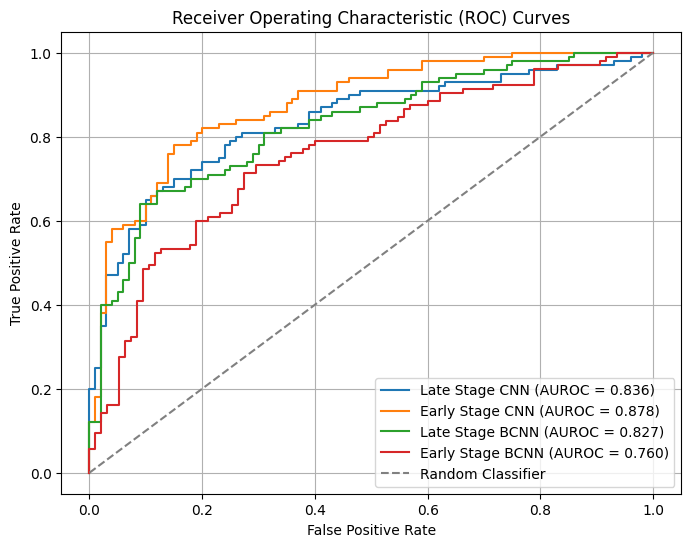

In [53]:

#FOR AUROC

#Model 1 (Early CNN) conversion done in AUROC cell
# Convert y2 and p2 (Late CNN) to numpy arrays and extract positive class probabilities
y2_np = np.array(y2)
p2_pos = np.array(p2)[:, 1]

# Convert y3 and p3 (Late BCNN) to numpy arrays and extract positive class probabilities
y3_np = np.array(y3)
p3_pos = np.array(p3)

# Convert y4 and p4 (Early BCNN) to numpy arrays and extract positive class probabilities
y4_np = np.array(y4)
p4_pos = np.array(p4)

# Calculate ROC curve and AUC for the early model cnn
fpr_model, tpr_model, _ = roc_curve(y_true_test, probs[:, 1])
auroc_model = roc_auc_score(y_true_test, probs[:, 1])

# Calculate ROC curve and AUC for the late stage cnn
fpr_y2, tpr_y2, _ = roc_curve(y2_np, p2_pos)
auroc_y2 = roc_auc_score(y2_np, p2_pos)

# Calculate ROC curve and AUC for the late model bcnn
fpr_y3, tpr_y3, _ = roc_curve(y3_np, p3_pos)
auroc_y3 = roc_auc_score(y3_np, p3_pos)

# Calculate ROC curve and AUC for the late bcnn
fpr_y4, tpr_y4, _ = roc_curve(y4_np, p4_pos)
auroc_y4 = roc_auc_score(y4_np, p4_pos)

# Plot both ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, label=f'Late Stage CNN (AUROC = {auroc_model:.3f})')
plt.plot(fpr_y2, tpr_y2, label=f'Early Stage CNN (AUROC = {auroc_y2:.3f})')
plt.plot(fpr_y3, tpr_y3, label=f'Late Stage BCNN (AUROC = {auroc_y3:.3f})')
plt.plot(fpr_y4, tpr_y4, label=f'Early Stage BCNN (AUROC = {auroc_y4:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUROC Curves')
plt.legend()
plt.grid(True)
plt.show()

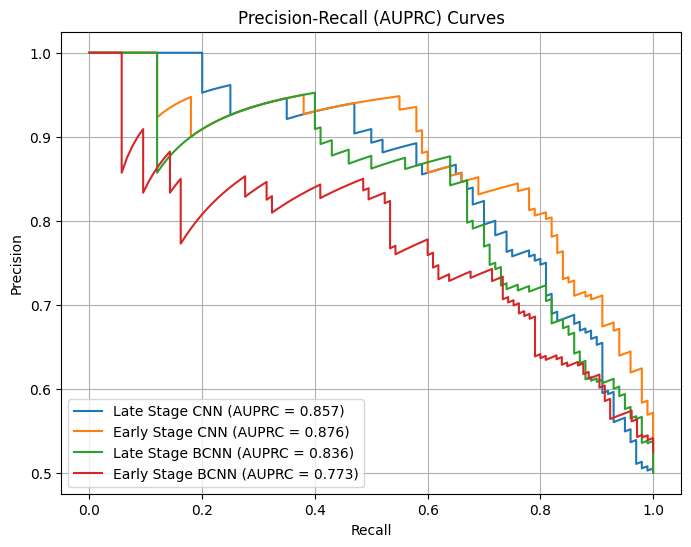

In [54]:
# AUPRC CURVES

from sklearn.metrics import precision_recall_curve, average_precision_score

# Model 1 (Early CNN)
fpr_model = probs[:, 1]

# Model 2 (Late CNN)
y2_np = np.array(y2)
p2_pos = np.array(p2)[:, 1]

# Model 3 (Late BCNN)
y3_np = np.array(y3)
p3_pos = np.array(p3)

# Model 4 (Early BCNN)
y4_np = np.array(y4)
p4_pos = np.array(p4)

# Calculate Precision-Recall curves and AUPRC
precision_model, recall_model, _ = precision_recall_curve(y_true_test, fpr_model)
auprc_model = average_precision_score(y_true_test, fpr_model)

precision_y2, recall_y2, _ = precision_recall_curve(y2_np, p2_pos)
auprc_y2 = average_precision_score(y2_np, p2_pos)

precision_y3, recall_y3, _ = precision_recall_curve(y3_np, p3_pos)
auprc_y3 = average_precision_score(y3_np, p3_pos)

precision_y4, recall_y4, _ = precision_recall_curve(y4_np, p4_pos)
auprc_y4 = average_precision_score(y4_np, p4_pos)

# Plot Precision-Recall curves
plt.figure(figsize=(8, 6))

plt.plot(recall_model, precision_model,
         label=f'Late Stage CNN (AUPRC = {auprc_model:.3f})')

plt.plot(recall_y2, precision_y2,
         label=f'Early Stage CNN (AUPRC = {auprc_y2:.3f})')

plt.plot(recall_y3, precision_y3,
         label=f'Late Stage BCNN (AUPRC = {auprc_y3:.3f})')

plt.plot(recall_y4, precision_y4,
         label=f'Early Stage BCNN (AUPRC = {auprc_y4:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall (AUPRC) Curves")
plt.legend(loc="lower left")
plt.grid(True)

plt.show()

## 15. One function to calculate all non-ELBO metrics

In [35]:
def calculate_binary_classification_metrics(y_true, probs, threshold=0.5, n_bins=10):
    """
    Calculate binary classification metrics from labels and probabilities.

    Args:
        y_true: shape [N], labels 0/1.
        probs: shape [N] containing P(class 1), or shape [N, 2].
        threshold: threshold for P(class 1), used only if probs has shape [N].
        n_bins: number of bins for ECE.

    Returns:
        metrics: dictionary
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        y_pred = probs_to_predictions(probs, threshold=threshold)
        p1 = probs
        probs_2d = np.column_stack([1.0 - p1, p1])
    else:
        y_pred = probs.argmax(axis=1)
        p1 = probs[:, 1]
        probs_2d = probs

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)

    metrics = {
        "accuracy": compute_accuracy(y_true, y_pred),
        "balanced_accuracy": compute_balanced_accuracy(y_true, y_pred),
        "auroc": compute_auroc(y_true, probs_2d),
        "auprc": compute_auprc(y_true, probs_2d),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "negative_log_likelihood": compute_negative_log_likelihood(y_true, probs_2d),
        "brier_score": compute_brier_score(y_true, probs_2d),
        "expected_calibration_error": compute_expected_calibration_error(y_true, probs_2d, n_bins=n_bins),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "positive_prevalence": float(np.mean(y_true == 1)),
    }

    return metrics

## 16. Wrapper for a standard neural network classifier (use later)

In [36]:
def evaluate_standard_nn_classifier(model, data_loader, device, n_bins=10):
    y_true, probs, y_pred = collect_predictions_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["cross_entropy_per_example"] = estimate_cross_entropy_per_example_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    return metrics, y_true, probs, y_pred

## 18. Demonstration with synthetic predictions

In [37]:
y_true_test, probs, y_pred = collect_predictions_standard_nn(
    model=model, # Use the model instance, not the class definition
    data_loader=test_loader,
    device=device,
)

metrics_demo = calculate_binary_classification_metrics(
    y_true=y_true_test,
    probs=probs,
    n_bins=10,
)

pd.DataFrame([metrics_demo]).T.rename(columns={0: "value"})



,value
accuracy,0.765000
balanced_accuracy,0.765000
auroc,0.835800
auprc,0.856502
sensitivity,0.710000
specificity,0.820000
negative_log_likelihood,0.494824
brier_score,0.162690
expected_calibration_error,0.030450
tn,82.000000


Confusion matrix [[TN, FP], [FN, TP]]:
[[82 18]
 [29 71]]


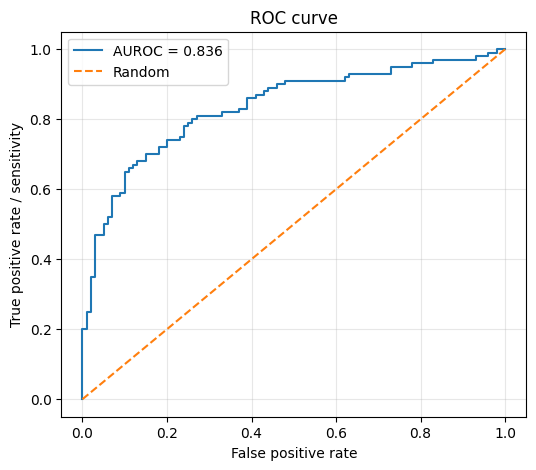

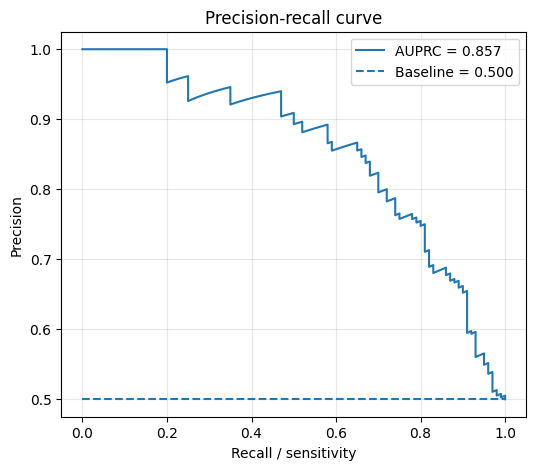

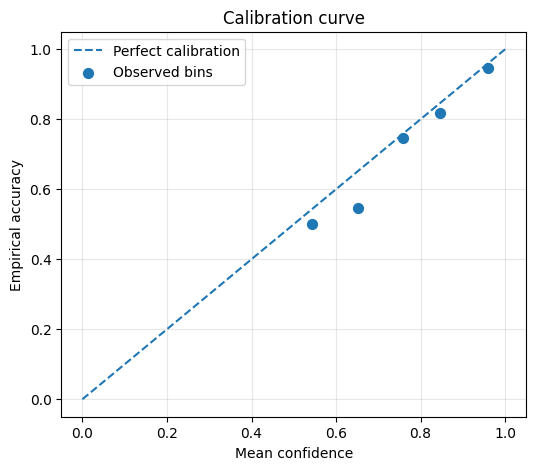

,bin,confidence_lower,confidence_upper,n,mean_confidence,empirical_accuracy,abs_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,0,NaN,NaN,NaN
2,3,0.2,0.3,0,NaN,NaN,NaN
3,4,0.3,0.4,0,NaN,NaN,NaN
4,5,0.4,0.5,0,NaN,NaN,NaN
5,6,0.5,0.6,16,0.542988,0.500000,0.042988
6,7,0.6,0.7,22,0.651628,0.545455,0.106173
7,8,0.7,0.8,59,0.758244,0.745763,0.012481
8,9,0.8,0.9,66,0.845547,0.818182,0.027365
9,10,0.9,1.0,37,0.960105,0.945946,0.014159


In [39]:

print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_true_test, y_pred, labels=[0, 1]))

plot_roc_curve(y_true_test, probs[:, 1])
plot_precision_recall_curve(y_true_test, probs[:, 1])
plot_calibration_curve(y_true_test, probs[:, 1], n_bins=10)
calibration_table(y_true_test, probs[:, 1],  n_bins=10)


## 19. How to use this with your ECG standard neural network

If you have a standard PyTorch CNN called `standard_cnn`, use:

```python
standard_metrics, standard_y, standard_probs, standard_pred = evaluate_standard_nn_classifier(
    model=standard_cnn,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

pd.DataFrame([standard_metrics], index=["standard CNN"])
```

The model must return logits of shape `[batch_size, 2]`.

## 20. How to use this with your ECG Bayesian neural network

If you have a Bayesian CNN called `bcnn` and guide called `bcnn_guide`, use:

```python
bayes_metrics, bayes_y, bayes_probs, bayes_pred = evaluate_bayesian_nn_classifier(
    model=bcnn,
    guide=bcnn_guide,
    data_loader=ts_test_loader,
    device=device,
    num_samples=100,
    n_bins=10,
    dataset_size=None,
)

pd.DataFrame([bayes_metrics], index=["Bayesian CNN"])
```

For training ELBO during minibatch training, `dataset_size` should usually be the full training-set size:

```python
train_dataset_size = len(ts_train_loader.dataset)
```

For held-out test-set reporting, using `dataset_size=None` gives an evaluation-style per-example estimate on the batches being evaluated.

## 21. Comparing a standard classifier and Bayesian classifier

Once both models have been evaluated, compare them side-by-side:

```python
comparison = pd.DataFrame(
    [standard_metrics, bayes_metrics],
    index=["standard CNN", "Bayesian CNN"],
)

comparison.T
```

Interpretation guidance:

| Metric | Better direction | What it emphasizes |
|---|---:|---|
| negative ELBO | lower | Bayesian posterior fit plus prior regularization |
| accuracy | higher | Overall hard-decision correctness |
| balanced accuracy | higher | Average performance across positive and negative classes |
| AUROC | higher | Ranking positives above negatives |
| AUPRC | higher | Positive-class retrieval, especially with imbalance |
| sensitivity | higher | Avoiding false negatives |
| specificity | higher | Avoiding false positives |
| negative log likelihood | lower | Probabilistic correctness; punishes confident errors |
| Brier score | lower | Mean squared probability error |
| expected calibration error | lower | Agreement between confidence and empirical accuracy |

For a medical classifier, raw accuracy is rarely enough. A Bayesian classifier may have similar accuracy to a standard classifier but better NLL, Brier score, ECE, or uncertainty behavior. That can still be valuable if uncertainty is clinically important.

## 22. Practical notes for Bayesian classifiers

### Use enough posterior samples

Bayesian predictions can be noisy if `num_samples` is small. For final evaluation, try values such as:

```python
num_samples = 100
num_samples = 250
num_samples = 500
```

and check whether the metrics stabilize.

### Calculate metrics from averaged probabilities

For Bayesian classifiers, do not calculate metrics from a single sampled network unless you specifically want to analyze one posterior draw. Usually, use:

$$
\bar p_i = \frac{1}{S}\sum_{s=1}^S p(y_i=1 \mid x_i, \theta^{(s)}).
$$

Then calculate accuracy, AUROC, AUPRC, NLL, Brier score, and ECE from \(\bar p_i\).

### Do not expect ELBO and accuracy to move identically

Negative ELBO optimizes probabilistic fit plus a KL penalty. Accuracy is a thresholded hard-decision metric. They are related but not equivalent.

### Report class prevalence

AUPRC and accuracy are easier to interpret when you also report:

$$
P(y=1).
$$

This notebook includes `positive_prevalence` in the metrics dictionary.

In [ ]:
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

# ==================================================
# 1. SAVE DIRECTORY SETUP
# ==================================================
run_name = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = Path(f"/content/drive/MyDrive/REU_CNN_Experiments/{run_name}")
save_dir.mkdir(parents=True, exist_ok=True)

plots_dir = save_dir / "plots"
plots_dir.mkdir(exist_ok=True)

# ==================================================
# 2. SAVE MODEL + DATA
# ==================================================
torch.save(ts_model.state_dict(), save_dir / "model_weights.pth")
torch.save(ts_model, save_dir / "full_model.pt")

pd.DataFrame([metrics_demo]).to_csv(save_dir / "metrics.csv", index=False)

cm = confusion_matrix(y_true_test, y_pred)

pd.DataFrame(
cm,
index=["True Neg", "True Pos"],
columns=["Pred Neg", "Pred Pos"]
).to_csv(save_dir / "confusion_matrix.csv")

pd.DataFrame({
"y_true": y_true_test,
"y_pred": y_pred,
"p_positive": probs[:, 1]
}).to_csv(save_dir / "predictions.csv", index=False)

# ==================================================
# 3. SAFE FIGURE SAVER
# ==================================================
def save_fig(fig, name):
  fig.savefig(plots_dir / name, bbox_inches="tight", dpi=300)
  plt.close(fig)

# ==================================================
# 4. PLOTTING FUNCTIONS (RETURN FIGURES — CRITICAL FIX)
# ==================================================

def plot_roc_curve(y_true, probs):
  fig, ax = plt.subplots()
  fpr, tpr, _ = roc_curve(y_true, probs)
  ax.plot(fpr, tpr, label="ROC")
  ax.plot([0, 1], [0, 1], "--")
  ax.set_title("ROC Curve")
  ax.legend()
  return fig


def plot_precision_recall_curve(y_true, probs):
  fig, ax = plt.subplots()
  precision, recall, _ = precision_recall_curve(y_true, probs)
  ax.plot(recall, precision)
  ax.set_title("Precision-Recall Curve")
  return fig


def plot_calibration_curve(y_true, probs, n_bins=10):
  fig, ax = plt.subplots()
  prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=n_bins)
  ax.plot(prob_pred, prob_true, marker="o")
  ax.set_title("Calibration Curve")
  return fig


def plot_history(history, title="Training History"):
  epochs = np.arange(1, len(history["train_loss"]) + 1)

  fig1, ax1 = plt.subplots(figsize=(7, 4))

  ax1.plot(epochs, history["train_loss"], label="train loss")

  if "test_loss" in history and len(history["test_loss"]) > 0:
    ax1.plot(epochs, history["test_loss"], label="test loss")

  ax1.set_xlabel("Epoch")
  ax1.set_ylabel("Loss")
  ax1.set_title(title + ": Loss")
  ax1.grid(True)
  ax1.legend()

  fig2, ax2 = plt.subplots(figsize=(7, 4))

  ax2.plot(epochs, history["train_acc"], label="train accuracy")

  if "test_acc" in history and len(history["test_acc"]) > 0:
    ax2.plot(epochs, history["test_acc"], label="test accuracy")

  ax2.set_xlabel("Epoch")
  ax2.set_ylabel("Accuracy")
  ax2.set_title(title + ": Accuracy")
  ax2.grid(True)
  ax2.legend()

  return fig1, fig2

# ==================================================
# 5. SAVE ALL PLOTS (NOW GUARANTEED NON-BLANK)
# ==================================================

fig = plot_roc_curve(y_true_test, probs[:, 1])
save_fig(fig, "roc_curve.png")

fig = plot_precision_recall_curve(y_true_test, probs[:, 1])
save_fig(fig, "precision_recall_curve.png")

fig = plot_calibration_curve(y_true_test, probs[:, 1], n_bins=10)
save_fig(fig, "calibration_curve.png")

fig1, fig2 = plot_history(ts_history, title="1D CNN Time-Series Classifier")

save_fig(fig1, "history_loss.png")
save_fig(fig2, "history_accuracy.png")

# ==================================================
# 6. EXTRA TABLE (CALIBRATION)
# ==================================================
calibration_table(y_true_test, probs[:, 1], n_bins=10).to_csv(
save_dir / "calibration_table.csv",
index=False
)

# ==================================================
# 7. DONE
# ==================================================
print(f"Saved experiment to {save_dir}")